# Analisa Data (A) — Reproduksi Skforecast Explainability

Notebook ini mereproduksi contoh dari dokumentasi skforecast 0.15.1 — Model Explainability:
https://skforecast.org/0.15.1/user_guides/explainability.html

Kita akan: (1) memuat data deret waktu, (2) membangun fitur lag, (3) melatih model peramalan (forecasting) menggunakan `ForecasterRecursive` dengan regressor LightGBM, (4) menjelaskan model menggunakan *feature importance* dan *SHAP values*.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive

shap.initjs()

## 2. Load Data

Dataset yang digunakan adalah `h2o_exog` (data bulanan dengan target `y` dan dua variabel eksogen). Dataset ini sering dipakai pada contoh-contoh resmi skforecast.

In [2]:
url = 'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/h2o_exog.csv'
data = pd.read_csv(url)
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
data = data.set_index('fecha')
data = data.asfreq('MS')
data = data.sort_index()
data.head()

,y,exog_1,exog_2
fecha,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199


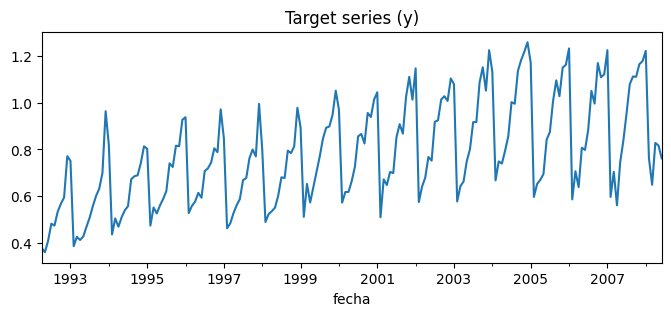

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
data['y'].plot(ax=ax, title='Target series (y)')
plt.show()

## 3. Split Data (Train / Test)

In [4]:
end_train = '2008-01-01'
data_train = data.loc[:end_train, :]
data_test  = data.loc[end_train:, :]

print(f"Train dates : {data_train.index.min()} -- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates  : {data_test.index.min()} -- {data_test.index.max()}  (n={len(data_test)})")

Train dates : 1992-04-01 00:00:00 -- 2008-01-01 00:00:00  (n=190)
Test dates  : 2008-01-01 00:00:00 -- 2008-06-01 00:00:00  (n=6)


## 4. Membuat dan Melatih Forecaster

Forecaster akan menggunakan 8 nilai lag dari `y`, ditambah variabel eksogen `exog_1` dan `exog_2`, sebagai input untuk model LightGBM.

In [5]:
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags = 8
)

forecaster.fit(
    y    = data_train['y'],
    exog = data_train[['exog_1', 'exog_2']]
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7 8] 
Window features: None 
Window size: 8 
Series name: y 
Exogenous included: True 
Exogenous names: exog_1, exog_2 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2008-01-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 04:31:43 
Last fit date: 2026-06-11 04:31:43 
Skforecast version: 0.22.0 
Python version: 3.12.3 
Forecaster id: None

## 5. Feature Importance

In [6]:
importances = forecaster.get_feature_importances()
importances

,feature,importance
9,exog_2,155
1,lag_2,99
6,lag_7,78
0,lag_1,66
8,exog_1,50
4,lag_5,47
5,lag_6,41
3,lag_4,38
7,lag_8,26
2,lag_3,21


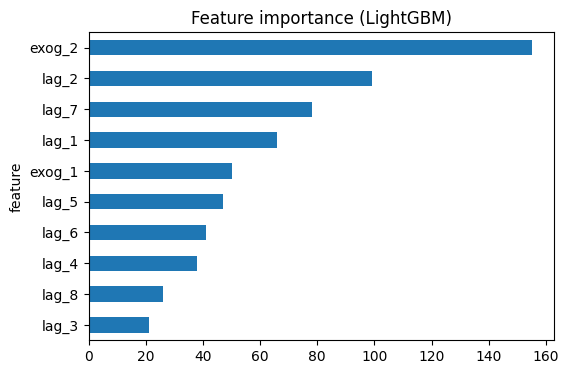

In [7]:
importances.set_index('feature')['importance'].sort_values().plot(
    kind='barh', figsize=(6, 4), title='Feature importance (LightGBM)'
)
plt.show()

## 6. SHAP Values

Untuk SHAP, kita memerlukan dua hal: regressor internal forecaster, dan matriks training (X, y) yang dipakai untuk fit. `create_train_X_y` mengembalikan matriks tersebut.

In [8]:
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['y'],
    exog = data_train[['exog_1', 'exog_2']]
)

explainer   = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

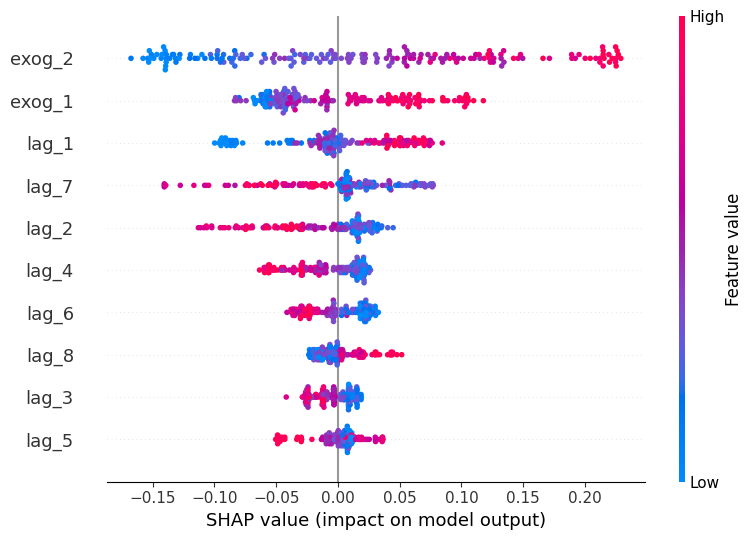

In [9]:
# Summary plot: pengaruh global tiap fitur terhadap prediksi
shap.summary_plot(shap_values, X_train)

In [10]:
# Force plot untuk satu observasi (observasi pertama)
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)

---
# Jawaban Pertanyaan

## 1. Analisis prediksi tentang apa?

Analisis ini tentang **peramalan deret waktu (time series forecasting)** menggunakan library **skforecast** dengan model regressor **LightGBM**. Targetnya adalah memprediksi nilai `y` di masa depan berdasarkan nilai-nilai historisnya sendiri (lag) dan dua variabel eksogen (`exog_1`, `exog_2`). Selain melakukan prediksi, notebook ini juga melakukan **explainability (interpretasi model)**, yaitu menjelaskan fitur apa saja yang paling berkontribusi terhadap hasil prediksi model, menggunakan dua pendekatan: *feature importance* bawaan model, dan *SHAP values*.

## 2. Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?

Data training dibentuk secara otomatis oleh `forecaster.create_train_X_y()` dari deret waktu `y` dan exog. Bentuknya adalah matriks tabular:

**Input (X_train)** — kolom-kolomnya terdiri dari:
- `lag_1, lag_2, ..., lag_8` → nilai `y` pada 1 sampai 8 periode sebelumnya (lag features).
- `exog_1`, `exog_2` → nilai variabel eksogen pada periode yang sedang diprediksi.

**Output (y_train)**:
- nilai `y` pada periode saat ini (target yang ingin diprediksi), sejajar/selaras dengan baris fitur lag-nya.

Jadi setiap baris pada data training merepresentasikan: "diberikan 8 nilai `y` sebelumnya + nilai exog saat ini, berapa nilai `y` sekarang?". Baris-baris dengan data tidak lengkap (di awal deret, karena belum ada cukup lag) otomatis dibuang.

## 3. Apa itu lag?

**Lag** adalah nilai dari deret waktu pada periode/waktu sebelumnya, yang digunakan sebagai variabel input (fitur) untuk memprediksi nilai pada periode saat ini atau berikutnya.

Contoh: jika `lags = 8`, maka untuk memprediksi `y` pada bulan ke-`t`, model menggunakan nilai `y` pada bulan `t-1, t-2, ..., t-8` sebagai fitur input (`lag_1` = `y` di `t-1`, `lag_2` = `y` di `t-2`, dst.). Konsep ini mengubah masalah peramalan deret waktu menjadi masalah regresi tabular biasa, sehingga model machine learning standar (seperti LightGBM, RandomForest, dll.) dapat digunakan.

## 4. Jelaskan proses analisis yang dilakukan dari kasus di atas

Proses analisis yang dilakukan adalah sebagai berikut:

1. **Memuat data** deret waktu bulanan (`h2o_exog`) yang berisi target `y` dan dua variabel eksogen (`exog_1`, `exog_2`), kemudian mengatur indeks waktunya.
2. **Membagi data** menjadi data latih (train) dan data uji (test) berdasarkan tanggal cutoff.
3. **Membangun forecaster** menggunakan `ForecasterRecursive` dari skforecast, dengan regressor LightGBM dan jumlah lag = 8. Forecaster ini secara otomatis mengubah deret waktu menjadi tabel fitur (lag + exog) dan target.
4. **Melatih model (fit)** menggunakan data latih beserta variabel eksogen.
5. **Menghitung feature importance**, yaitu seberapa besar kontribusi tiap fitur (lag dan exog) terhadap keputusan model LightGBM secara global, lalu memvisualisasikannya dalam bar chart.
6. **Menghitung SHAP values** menggunakan `shap.TreeExplainer` pada regressor internal forecaster dan matriks training (X_train). SHAP memberikan penjelasan yang lebih detail dan adil (berbasis teori game) tentang kontribusi setiap fitur terhadap setiap prediksi individual.
7. **Visualisasi hasil explainability**:
   - `summary_plot`: menunjukkan distribusi pengaruh tiap fitur terhadap seluruh prediksi (pengaruh global).
   - `force_plot`: menunjukkan secara rinci bagaimana setiap fitur mendorong prediksi naik/turun dari nilai dasar (*expected value*) untuk satu observasi tertentu (pengaruh lokal).

Secara keseluruhan, analisis ini tidak hanya membangun model peramalan, tetapi juga **membuka 'kotak hitam' (black box)** model machine learning tersebut — menjelaskan fitur (lag mana, atau variabel eksogen mana) yang paling berpengaruh terhadap hasil prediksi, baik secara global maupun untuk satu titik data spesifik.